### Importation librairies

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import os
from torchvision import transforms
from torchvision.transforms import v2 
from tqdm import tqdm
from PIL import Image, ImageOps

### Exploration & Visualisation 

In [2]:
root_dir = "BHI_extracted"  

healthy_images = []
cancer_images = []

for patient_folder in os.listdir(root_dir):
    patient_path = os.path.join(root_dir, patient_folder)
    if os.path.isdir(patient_path):
        healthy_path = os.path.join(patient_path, "0")
        if os.path.isdir(healthy_path):
            healthy_images += [os.path.join(healthy_path, img) for img in os.listdir(healthy_path)]
        cancer_path = os.path.join(patient_path, "1")
        if os.path.isdir(cancer_path):
            cancer_images += [os.path.join(cancer_path, img) for img in os.listdir(cancer_path)]

print(f"Nombre d'images saines : {len(healthy_images)}")
print(f"Nombre d'images cancéreuses : {len(cancer_images)}")

Nombre d'images saines : 198738
Nombre d'images cancéreuses : 78786


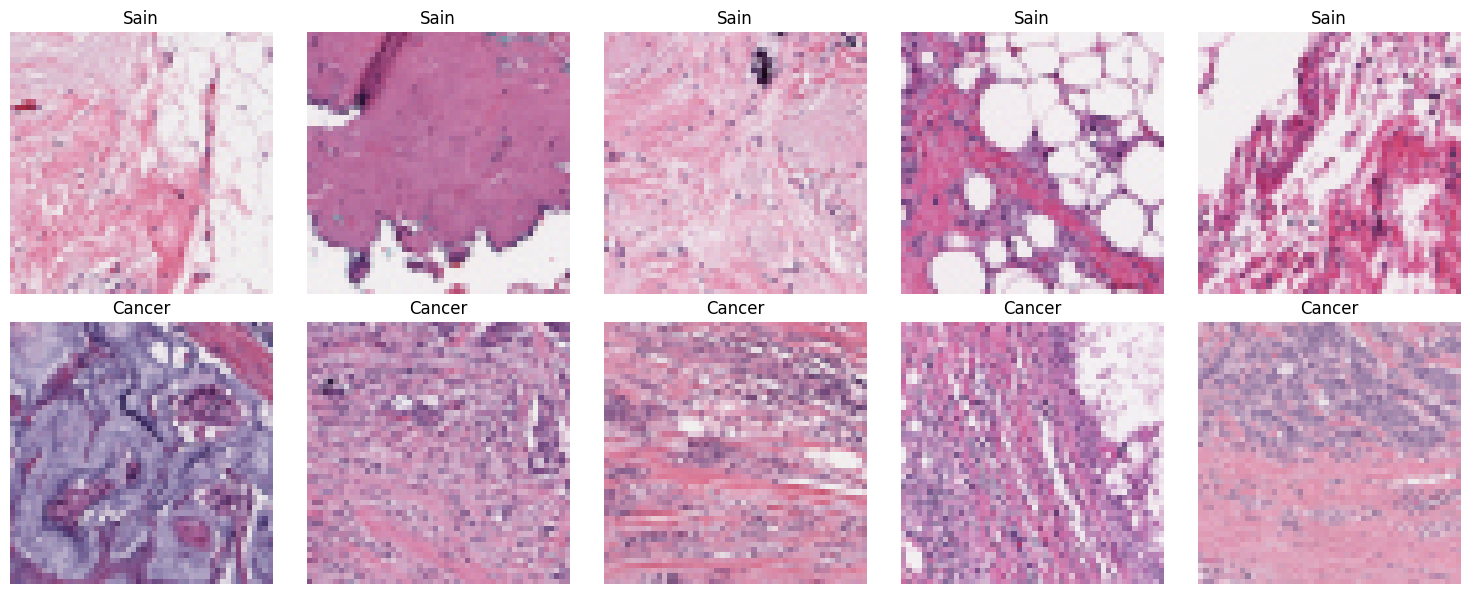

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    img_healthy = Image.open(random.choice(healthy_images))
    axes[0, i].imshow(img_healthy)
    axes[0, i].set_title("Sain")
    axes[0, i].axis("off")
    img_cancer = Image.open(random.choice(cancer_images))
    axes[1, i].imshow(img_cancer)
    axes[1, i].set_title("Cancer")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [4]:
from PIL import Image

# Taille de 10 images saines au hasard
healthy_shapes = [Image.open(path).size for path in random.sample(healthy_images, 10)]
# Taille de 10 images cancéreuses au hasard
cancer_shapes = [Image.open(path).size for path in random.sample(cancer_images, 10)]

print("Taille d'images saines (exemple) :", healthy_shapes)
print("Taille d'images cancéreuses (exemple) :", cancer_shapes)


Taille d'images saines (exemple) : [(50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50)]
Taille d'images cancéreuses (exemple) : [(50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50)]


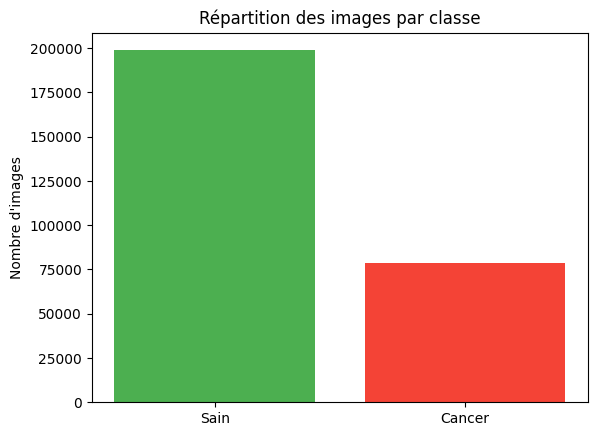

In [5]:
import matplotlib.pyplot as plt

labels = ["Sain", "Cancer"]
counts = [len(healthy_images), len(cancer_images)]

plt.bar(labels, counts, color=["#4CAF50", "#F44336"])
plt.title("Répartition des images par classe")
plt.ylabel("Nombre d'images")
plt.show()

### Data augmentation

In [7]:
aug_cancer_dir = "aug_cancer"
os.makedirs(aug_cancer_dir, exist_ok=True)

n_aug = 1

for img_path in tqdm(cancer_images, desc="Flip horizontal images cancéreuses"):
    try:
        img = Image.open(img_path)
        base = os.path.splitext(os.path.basename(img_path))[0]
        for i in range(n_aug):
            aug_img = ImageOps.mirror(img)  # flip horizontal
            save_path = os.path.join(aug_cancer_dir, f"{base}_flipH_{i}.png")
            aug_img.save(save_path)
    except Exception as e:
        print(f"Erreur avec {img_path}: {e}")

Flip horizontal images cancéreuses: 100%|██████████| 78786/78786 [07:07<00:00, 184.15it/s]


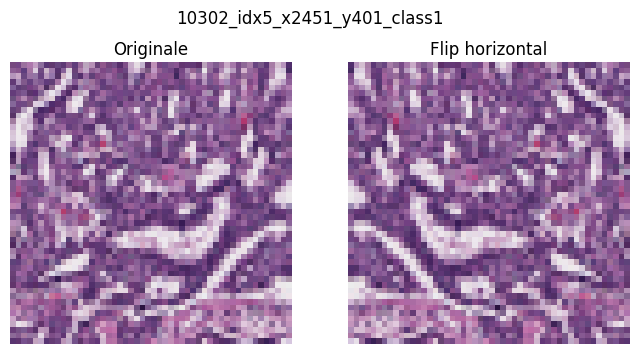

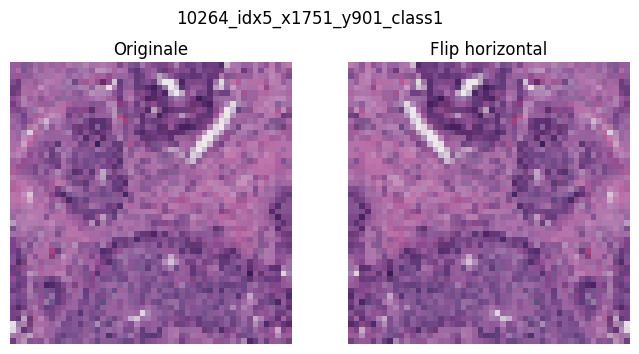

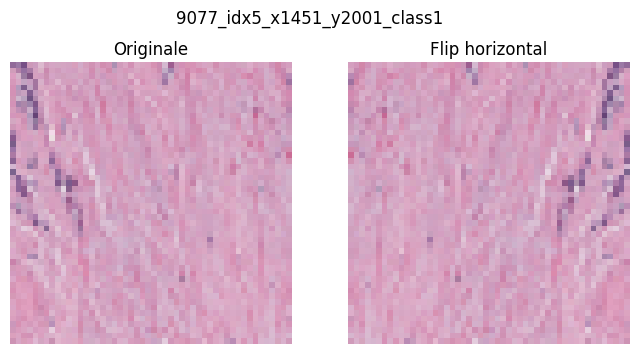

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Choix aléatoire de 3 images originales de la liste
sample_imgs = random.sample(cancer_images, 3)

for img_path in sample_imgs:
    # Image originale
    orig = Image.open(img_path)
    base = os.path.splitext(os.path.basename(img_path))[0]
    # Image miroir
    flip_path = os.path.join('aug_cancer', f"{base}_flipH_0.png")
    flipped = Image.open(flip_path)

    # Affichage côte à côte
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(orig)
    axs[0].set_title('Originale')
    axs[0].axis('off')
    axs[1].imshow(flipped)
    axs[1].set_title('Flip horizontal')
    axs[1].axis('off')
    plt.suptitle(base)
    plt.show()

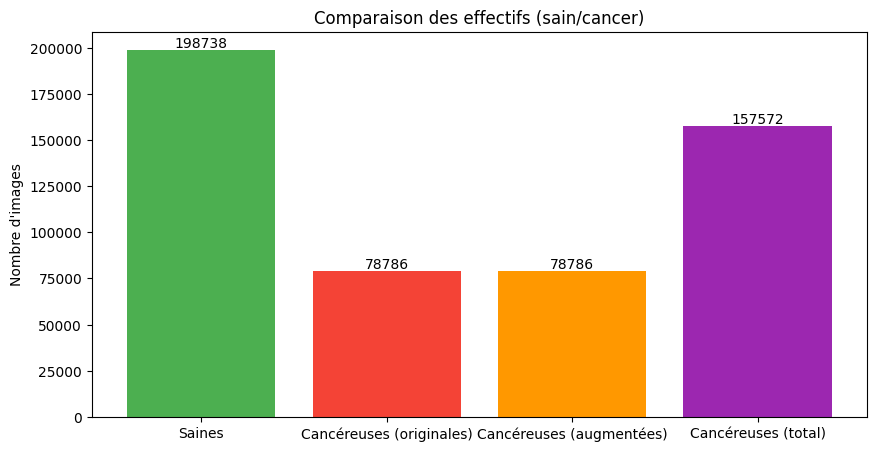

In [9]:
# Nb d'images saines 
nb_healthy = len(healthy_images)

# Nb images cancéreuses originales
nb_cancer_orig = len(cancer_images)

# Nb d'images cancéreuses augmentées 
aug_cancer_dir = "aug_cancer"
nb_cancer_aug = len(os.listdir(aug_cancer_dir))

# Nb total
nb_cancer_total = nb_cancer_orig + nb_cancer_aug

# Affichage histogramme
labels = ["Saines", "Cancéreuses (originales)", "Cancéreuses (augmentées)", "Cancéreuses (total)"]
values = [nb_healthy, nb_cancer_orig, nb_cancer_aug, nb_cancer_total]

plt.figure(figsize=(10,5))
bars = plt.bar(labels, values, color=["#4CAF50", "#F44336", "#FF9800", "#9C27B0"])
plt.ylabel("Nombre d'images")
plt.title("Comparaison des effectifs (sain/cancer)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', va='bottom', ha='center')
plt.show()